In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pickle
import swifter
import configparser
from typing import List
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import json
from tqdm import tqdm

from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from hdbscan import HDBSCAN
import hyperopt as hp

import torch as t
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch import Tensor
import torch.nn.functional as F

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from mlx_lm import load, generate
from mlx_lm.sample_utils import make_sampler

from visualization_utils import TruthData
from generate_acts import load_model
from rephrasing import load_model_and_tokenizer
from prompts import PROMPTS
from pprint import pprint

/opt/miniconda3/envs/LLM_Dez/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
nltk.download('stopwords') # comment out if already downloaded
nltk.download('punkt')     # comment out if already downloaded
nltk.download('wordnet')

stops_eng = set(stopwords.words('english'))

In [ ]:
wnl = WordNetLemmatizer()
def clean_text(feature):

    feature = [wnl.lemmatize(word.lower()) for word in nltk.word_tokenize(feature) if word.lower() not in stops_eng]
    return " ".join(feature)

In [2]:
model_to_analyse = "Qwen3-4B"
config = configparser.ConfigParser()
config.read('config.ini')
layer = 5 #48
#eval(config[model]['probe_layer'])
noperiod = eval(config[model_to_analyse]['noperiod'])

device = "mps" #'cuda:0' if torch.cuda.is_available() else 'cpu'

In [3]:
df_acts = TruthData.from_datasets(
    ["hatecheck"], #[knowledge_non_knowledge_original_v3_categorized, knowledge_non_knowledge_v3_rephrased_gpt_120b], # datasets to use
    model=model_to_analyse,
    layer=layer,
    center=True,
    noperiod=noperiod,
    #symbols=symbols,
    device=device
)
#pprint(df_acts.df)
#df_acts.df = df_acts.df[df_acts.df["binary_NK_label"] == 1]
pca_datasets = df_acts.df.index.levels[0].tolist()
acts = df_acts.df.loc[pca_datasets]['activation'].tolist()
acts = t.stack(acts, dim=0).numpy()

df_data = pd.read_csv("datasets/hatecheck.csv")
#df_data = df_data[df_data["binary_NK_label"] == 1]
#df_data["statement"] = df_data["statement"].swifter.apply(clean_text)
statements = df_data["statement"].tolist()
labels = df_data["functionality"].tolist()
binary_labels = df_data["is_toxic"].tolist()
#roberts_labels = df_data["Roberts_label"].tolist()
#fse_labels = df_data["FSE_label"].tolist()

Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-4B/hatecheck
3728


In [38]:
class ClusterOptimise:

    def __init__(self, embedding, label_lower, label_upper, max_evals):
        self.embedding = embedding
        self.label_lower = label_lower
        self.label_upper = label_upper
        self.max_evals = max_evals

    def generate_clusters(
            self, 
            n_neighbors, 
            n_components_umap,
            n_components_tsne,
            perplexity, 
            min_cluster_size, 
            min_samples, 
            random_state=None):
        
        umap_embeddings = UMAP(n_neighbors=int(n_neighbors),
                               n_components=int(n_components_umap),
                               metric='euclidean',
                               random_state=int(random_state)).fit_transform(self.embedding)
        
        tsne_embeddings = TSNE(n_components=int(n_components_tsne),
                              perplexity=perplexity,
                              metric="euclidean",
                              method="exact",
                              random_state=int(random_state)).fit_transform(umap_embeddings)

        clusters = HDBSCAN(min_cluster_size=int(min_cluster_size),
                           min_samples=int(min_samples),
                           cluster_selection_method="leaf",
                           gen_min_span_tree = True).fit(tsne_embeddings)
        return umap_embeddings, clusters

    def relative_validity_(self, hdbscan_model):

        labels = hdbscan_model.labels_
        sizes = np.bincount(labels + 1)
        noise_size = sizes[0]
        cluster_size = sizes[1:]
        total = noise_size + np.sum(cluster_size)
        num_clusters = len(cluster_size)
        DSC = np.zeros(num_clusters)
        min_outlier_sep = np.inf  # only required if num_clusters = 1
        correction_const = 2  # only required if num_clusters = 1

        # Unltimately, for each Ci, we only require the
        # minimum of DSPC(Ci, Cj) over all Cj != Ci.
        # So let's call this value DSPC_wrt(Ci), i.e.
        # density separation 'with respect to' Ci.
        DSPC_wrt = np.ones(num_clusters) * np.inf
        max_distance = 0

        mst_df = hdbscan_model.minimum_spanning_tree_.to_pandas()

        for edge in mst_df.iterrows():
            label1 = labels[int(edge[1]["from"])]
            label2 = labels[int(edge[1]["to"])]
            length = edge[1]["distance"]

            max_distance = max(max_distance, length)

            if label1 == -1 and label2 == -1:
                continue
            elif label1 == -1 or label2 == -1:
                # If exactly one of the points is noise
                min_outlier_sep = min(min_outlier_sep, length)
                continue

            if label1 == label2:
                # Set the density sparseness of the cluster
                # to the sparsest value seen so far.
                DSC[label1] = max(length, DSC[label1])
            else:
                # Check whether density separations with
                # respect to each of these clusters can
                # be reduced.
                DSPC_wrt[label1] = min(length, DSPC_wrt[label1])
                DSPC_wrt[label2] = min(length, DSPC_wrt[label2])

        # In case min_outlier_sep is still np.inf, we assign a new value to it.
        # This only makes sense if num_clusters = 1 since it has turned out
        # that the MR-MST has no edges between a noise point and a core point.
        min_outlier_sep = max_distance if min_outlier_sep == np.inf else min_outlier_sep

        # DSPC_wrt[Ci] might be infinite if the connected component for Ci is
        # an "island" in the MR-MST. Whereas for other clusters Cj and Ck, the
        # MR-MST might contain an edge with one point in Cj and ther other one
        # in Ck. Here, we replace the infinite density separation of Ci by
        # another large enough value.
        #
        # TODO: Think of a better yet efficient way to handle this.
        correction = correction_const * (
            max_distance if num_clusters > 1 else min_outlier_sep
        )
        DSPC_wrt[np.where(DSPC_wrt == np.inf)] = correction

        V_index = [
            (DSPC_wrt[i] - DSC[i]) / max(DSPC_wrt[i], DSC[i])
            for i in range(num_clusters)
        ]
        score = np.sum(
            [(cluster_size[i] * V_index[i]) / total for i in range(num_clusters)]
        )
        self._relative_validity = score
        return self._relative_validity


    def objective(self, params):
        """
        Objective function for hyperopt to minimize, which incorporates constraints
        on the number of clusters we want to identify
        """

        _, clusters = self.generate_clusters(params['n_neighbors'],
                                          params['n_components_umap'],
                                          params['n_components_tsne'],
                                          params['perplexity'],
                                          params['min_cluster_size'],
                                          params['min_samples'],
                                          params['random_state'])

        validity_score = self.relative_validity_(clusters)
        label_count = len(np.unique(clusters.labels_))

        # 15% penalty on the cost function if outside the desired range of groups
        penalty = 0.5 if (label_count < self.label_lower) or (label_count > self.label_upper) else 0
        adj_score = -validity_score + penalty   #vorzeichen geändert für Minimierungsproblem

        return {'loss': adj_score, 'label_count': label_count, 'status': hp.STATUS_OK}

    def bayesian_search(self, space):
        """
        Perform bayseian search on hyperopt hyperparameter space to minimize objective function
        """

        trials = hp.Trials()
        fmin_objective = lambda params: self.objective(params)
        best = hp.fmin(fmin_objective,
                    space=space,
                    algo=hp.tpe.suggest,
                    max_evals=self.max_evals,
                    trials=trials)

        best_params = hp.space_eval(space, best)
        print('best:')
        print(best_params)
        print(f"label count: {trials.best_trial['result']['label_count']}")

        """umap, best_clusters = self.generate_clusters(best_params['n_neighbors'],
                                               best_params['n_components'],
                                               best_params['min_cluster_size'],
                                               best_params['min_samples'],
                                               best_params['random_state'])"""

        return best_params, trials

In [39]:
dataset = "hatecheck"

hspace = {
    "n_neighbors" : hp.hp.quniform("n_neighbors", 5, 50, 2), # (20, 50, 2)
    "n_components_umap" : hp.hp.quniform("n_components_umap", 10, 40, 2), # (10, 30, 2)
    "n_components_tsne" : hp.hp.quniform("n_components_tsne", 2, 12, 2),
    "perplexity" : hp.hp.quniform("perplexity", 5, 50, 2),
    "min_cluster_size" : hp.hp.quniform("min_cluster_size", 25, 500, 2), # (600, 200, 10)
    "min_samples" : hp.hp.quniform("min_samples", 5, 50, 2),
    "random_state" : 42
}

models_to_analyse = ["Qwen3-4B"]#, "Qwen3-8B", "Qwen3-14B", "Qwen3-32B"]
config = configparser.ConfigParser()
config.read('config.ini')
#eval(config[model]['probe_layer'])
device = "mps" #'cuda:0' if torch.cuda.is_available() else 'cpu'
for model_name in models_to_analyse:
    #model = load_model(model_name, device)
    layers = [3, 9, 18, 30] #list(range(len(model.model.layers)))
    params = {layer: {algo: {} for algo in ["UMAP", "HDBSCAN"]} for layer in layers}
    noperiod = eval(config[model_name]['noperiod'])
    df_data_test = pd.read_csv(f"datasets/{dataset}.csv")
    statements = df_data["statement"].tolist()
    labels = df_data["functionality"].tolist()
    binary_labels = df_data["is_toxic"].tolist()
    label_lower = 2
    label_upper = 30
    max_evals = 25
    for layer in layers:
        df_acts = TruthData.from_datasets(
            [dataset], #[knowledge_non_knowledge_original_v3_categorized, knowledge_non_knowledge_v3_rephrased_gpt_120b], # datasets to use
            model=model_name,
            layer=layer,
            center=True,
            noperiod=noperiod,
            #symbols=symbols,
            device=device
        )
        #pprint(df_acts.df)
        #df_acts.df = df_acts.df[df_acts.df["binary_NK_label"] == 1]
        pca_datasets = df_acts.df.index.levels[0].tolist()
        acts = df_acts.df.loc[pca_datasets]['activation'].tolist()
        acts = t.stack(acts, dim=0).numpy()

        DCBV_optimise = ClusterOptimise(acts, label_lower=label_lower, label_upper=label_upper, max_evals=max_evals)
        best_params_use, trials_use = DCBV_optimise.bayesian_search(space=hspace)

        umap_args = {
            "n_neighbors" : int(best_params_use["n_neighbors"]),
            "n_components" : int(best_params_use["n_components_umap"]),
            'min_dist': 0.1,
            "metric": "euclidean",
            "random_state": 42
        }

        tsne_args = {
            "n_components" : int(best_params_use["n_components_tsne"]),
            "perplexity" : int(best_params_use["perplexity"]),
            "metric" : "euclidean",
            "method" : "exact",
            "random_state" : 42
        }
        #params[layer]["UMAP"] = umap_args

        hdbscan_args = {
            "min_cluster_size" : int(best_params_use["min_cluster_size"]),
            "min_samples" : int(best_params_use["min_samples"]),
            "prediction_data" : True,
            'cluster_selection_method': 'leaf'
        }
        params[layer]["HDBSCAN"] = umap_args

        umap_embeddings = UMAP(**umap_args).fit_transform(acts)
        tsne_embedding = TSNE(**tsne_args).fit_transform(umap_embeddings)
        hdbscan_model = HDBSCAN(**hdbscan_args).fit(tsne_embedding)

        df_data_test[f"layer{layer}_cluster"] = hdbscan_model.labels_

    # with open('all_toxicity_results/experimental_outputs/{model_name}_{args.datasets[0]}_hyperparameters.json', 'w') as f:
    #     json.dump(params, f, indent=4)
    
    df_data_test.to_csv(f"all_toxicity_results/experimental_outputs/{model_name}_{dataset}_layerwise_cluster.csv", sep=",")

Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-4B/hatecheck
3728
  0%|          | 0/25 [00:00<?, ?trial/s, best loss=?]

/opt/miniconda3/envs/LLM_Dez/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  4%|▍         | 1/25 [02:48<1:07:32, 168.84s/trial, best loss: -0.0027923295157613196]

/opt/miniconda3/envs/LLM_Dez/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  8%|▊         | 2/25 [08:00<1:36:49, 252.58s/trial, best loss: -0.21259838006778714]  

...

/opt/miniconda3/envs/LLM_Dez/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



 20%|██        | 5/25 [18:55<1:15:13, 225.66s/trial, best loss: -0.3625606516087932]

/opt/miniconda3/envs/LLM_Dez/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



 20%|██        | 5/25 [21:19<1:25:18, 255.94s/trial, best loss: -0.3625606516087932]


KeyboardInterrupt: 

In [7]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import MaximalMarginalRelevance, KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
hspace = {
    "n_neighbors" : hp.hp.quniform("n_neighbors", 5, 50, 2), # (20, 50, 2)
    "n_components" : hp.hp.quniform("n_components", 2, 30, 2), # (10, 30, 2)
    "min_cluster_size" : hp.hp.quniform("min_cluster_size", 25, 500, 2), # (600, 200, 10)
    "min_samples" : hp.hp.quniform("min_samples", 5, 50, 2),
    "random_state" : 42
}

label_lower = 2
label_upper = 30
max_evals = 1

vectorizer_model = CountVectorizer(ngram_range=(1, 2))
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = MaximalMarginalRelevance(diversity=0.3)
# # Let's go through every json file in BigNews
# # for i, (embedding_name, parquet_name) in enumerate(zip(sorted(os.listdir(path_to_embeddings)), sorted(os.listdir(path_to_lemmatized)))):
# #     with h5py.File(path_to_embeddings + embedding_name, 'r') as f:
# #         embedding = f['embedding'][:]

# #     print("+++++", corpora[i], "+++++")
# #     #print(embedding_name, parquet_name)
# #     df_in = pd.read_parquet(path_to_lemmatized + parquet_name)
# #     #print(embedding.shape)
# #     # load speeches into a list
# #     speeches = df_in["text"].to_list()

DCBV_optimise = ClusterOptimise(acts, label_lower=label_lower, label_upper=label_upper, max_evals=max_evals)
best_params_use, trials_use = DCBV_optimise.bayesian_search(space=hspace)

umap_args = {
    "n_neighbors" : int(best_params_use["n_neighbors"]),
    "n_components" : int(best_params_use["n_components_umap"]),
    'min_dist': 0.1,
    "metric": "euclidean",
    "random_state": 42
}

tsne_args = {
    "n_components" : int(best_params_use["n_components_tsne"]),
    "perplexity" : int(best_params_use["perplexity"]),
    "metric" : "euclidean",
    "random_state" : 42
}


hdbscan_args = {
    "min_cluster_size" : int(best_params_use["min_cluster_size"]),
    "min_samples" : int(best_params_use["min_samples"]),
    "prediction_data" : True,
    'cluster_selection_method': 'leaf'
}

#pca = PCA(**pca_args).fit(acts)
umap_model = UMAP(**umap_args).fit(acts)
hdbscan_model = HDBSCAN(**hdbscan_args)

# All steps together
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,            # Step 1 - Cluster reduced embeddings
    vectorizer_model=vectorizer_model,        # Step 2 - Tokenize topics
    ctfidf_model=ctfidf_model,                # Step 3 - Extract topic words
    representation_model=representation_model,# Step 4 - (Optional) Fine-tune topic represenations
    verbose = True
)

topics = topic_model.fit_transform(statements, embeddings=acts)
df_data["topic_lables"] = topic_model.topics_

100%|██████████| 1/1 [00:20<00:00, 20.77s/trial, best loss: -0.13198095755979625]
best:
{'min_cluster_size': 182.0, 'min_samples': 42.0, 'n_components': 20.0, 'n_neighbors': 22.0, 'random_state': 42}
label count: 7


2025-12-17 15:22:15,313 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-17 15:22:35,848 - BERTopic - Dimensionality - Completed ✓
2025-12-17 15:22:35,848 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-17 15:22:35,936 - BERTopic - Cluster - Completed ✓
2025-12-17 15:22:35,937 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-17 15:22:35,961 - BERTopic - Representation - Completed ✓


In [ ]:
topics = topic_model.fit_transform(statements, embeddings=acts)
df_data["topic_lables"] = topic_model.topics_

In [5]:
df_data = pd.read_csv("all_toxicity_results/experimental_outputs/Qwen3-4B_hatecheck_layerwise_cluster.csv")

In [8]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,functionality,case_id,statement,label_gold,target_ident,direction,focus_words,focus_lemma,...,Qwen3-4B_layer26_cluster,Qwen3-4B_layer27_cluster,Qwen3-4B_layer28_cluster,Qwen3-4B_layer29_cluster,Qwen3-4B_layer30_cluster,Qwen3-4B_layer31_cluster,Qwen3-4B_layer32_cluster,Qwen3-4B_layer33_cluster,Qwen3-4B_layer34_cluster,Qwen3-4B_layer35_cluster
0,0,0,derog_neg_emote_h,1,I hate women.,hateful,women,general,hate,hate,...,2,2,3,5,5,3,2,3,8,5
1,1,1,derog_neg_emote_h,2,I hate trans people.,hateful,trans people,general,hate,hate,...,2,2,3,5,-1,3,2,3,8,5
2,2,2,derog_neg_emote_h,3,I hate gay people.,hateful,gay people,general,hate,hate,...,2,2,3,5,5,3,2,3,8,5
3,3,3,derog_neg_emote_h,4,I hate black people.,hateful,black people,general,hate,hate,...,2,2,3,5,5,3,2,3,8,5
4,4,4,derog_neg_emote_h,5,I hate disabled people.,hateful,disabled people,general,hate,hate,...,2,2,3,5,5,3,2,3,8,5


In [112]:
#df_topics = df_data.groupby(by="topic_lables")["original_statement", "statement"]
model_name = "gemma-3-27b-it"
config = configparser.ConfigParser()
config.read('config.ini')
layer_a = eval(config[model_name]['probe_layer_a'])
layer_b1 = eval(config[model_name]['probe_layer_b1'])
layer_b2 = eval(config[model_name]['probe_layer_b2'])
layer_c = eval(config[model_name]['probe_layer_c'])
noperiod = eval(config[model_name]['noperiod'])
device = "mps" #'cuda:0' if torch.cuda.is_available() else 'cpu'

layer = layer_c

df_acts = TruthData.from_datasets(
    ["hatecheck"], #[knowledge_non_knowledge_original_v3_categorized, knowledge_non_knowledge_v3_rephrased_gpt_120b], # datasets to use
    model=model_name,
    layer=layer,
    center=True,
    noperiod=noperiod,
    #symbols=symbols,
    device=device
)
pca_datasets = df_acts.df.index.levels[0].tolist()
acts = df_acts.df.loc[pca_datasets]['activation'].tolist()
acts = t.stack(acts, dim=0).numpy()

df_data = pd.read_csv(f"all_toxicity_results/experimental_outputs/{model_name}_hatecheck_layerwise_cluster_partial.csv")
statements = df_data["statement"].tolist()
labels = df_data["functionality"].tolist()
binary_labels = df_data["is_toxic"].tolist()

df_topics = df_data.groupby(f'{model_name}_layer{layer}_cluster').agg({
    #'original_statement': list,
    'statement': list,
    #"Repo": list,
    #"GitHub_Type": list
    "functionality": list,
    "target_ident": list
})

Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/hatecheck
3728


In [113]:
acts

array([[-213.24127 , -107.224976,  403.11975 , ...,  235.50214 ,
         309.44427 , -132.64203 ],
       [  54.758728,  204.77502 , -388.88025 , ..., -272.49786 ,
         205.44427 , -148.64203 ],
       [ 410.75873 ,  298.77502 , -172.88025 , ..., -316.49786 ,
        -108.555725, -444.64203 ],
       ...,
       [ 602.7587  , -377.22498 , -380.88025 , ...,  173.50214 ,
         -22.555725,  105.35797 ],
       [ 594.7587  ,  218.77502 , -180.88025 , ...,   87.50214 ,
         349.44427 , -248.64203 ],
       [ 318.75873 , -125.224976,   -4.880249, ...,  211.50214 ,
         243.44427 , -292.64203 ]], shape=(3728, 5376), dtype=float32)

In [ ]:
df_topics

In [ ]:
model_name = "gpt-oss-120b"
model, tokenizer = load_model_and_tokenizer(model_name)

In [ ]:
from collections import Counter
for label, row in df_topics.iterrows():
    print(f"### {label} ###")
    repos = row["functionality"]
    types = row["target_ident"]
    repo_count = Counter(repos)
    type_count = Counter(types)
    print(repo_count)
    print(type_count)
    print()

In [ ]:
NK_topics = {}
for label, row in df_topics.iterrows():
    texts = row["statement"]
    deduplicated = list(dict.fromkeys(texts))
    messages = [
        {
            "role": "system",
            "content": PROMPTS["ANALYZE_TOXICITY_SYSTEM_PROMPT"]
        },
        {
            "role": "user",
            "content": PROMPTS["ANALYZE_TOXICITY_INPUT_PROMPT"].format(documents=deduplicated)
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True
    )
    
    sampler = make_sampler(temp=0.7, top_p=0.9, top_k=20, min_p=0)
    # Generate response
    response = generate(
        model,
        tokenizer,
        sampler=sampler,
        prompt=prompt,
        max_tokens=8192
    )

    response_split = response.split("<|end|><|start|>assistant<|channel|>final<|message|>")
    thinking_content = response_split[0]
    content = response_split[1]
    NK_topics[label] = content

In [ ]:
from IPython.display import Markdown, display

display(Markdown(NK_topics[3]))
#pprint(NK_topics[1]

In [ ]:
topic_texts = df_topics["statement"][1]
deduplicated = list(dict.fromkeys(topic_texts))
for text in deduplicated:
    display(text)

/opt/miniconda3/envs/LLM_Dez/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


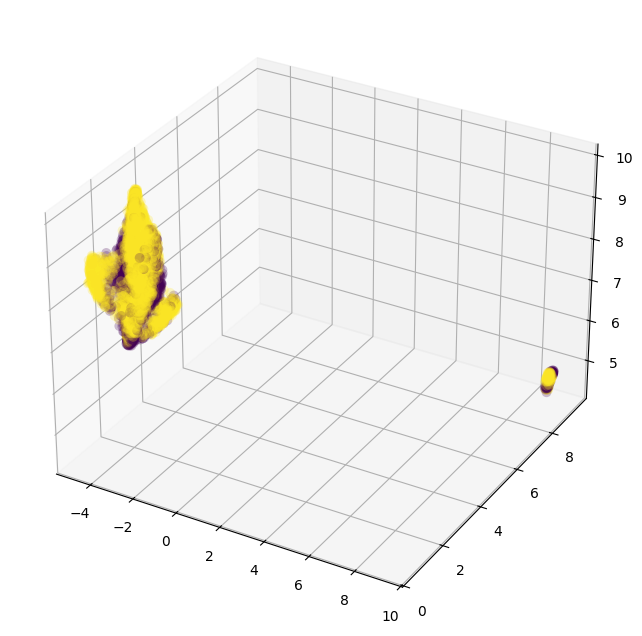

In [109]:
import seaborn as sns

with open(f"all_toxicity_results/experimental_outputs/{model_name}_hatecheck_hyperparameters_partial.json", "r") as f:
    d = json.load(f)
    umap_params = d[f"{layer}"]["UMAP"]
projection = UMAP(**umap_params).fit_transform(acts)
#projection = PCA(**pca_args).fit_transform(acts)
color_palette = sns.color_palette('Paired', 12)
cluster_colors = [color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  #for x in hdbscan_model.labels_]
                  for x in df_data[f"{model_name}_layer{layer}_cluster"]]
#cluster_member_colors = [sns.desaturate(x, p) for x, p in
#                         zip(cluster_colors, hdbscan_model.probabilities_)]
#px.scatter_3d(projection, projection[:,0], projection[:,1], projection[:,2], color = cluster_member_colors)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
dim_offset = 1
if umap_params["n_components"] >= 3:
    ax.scatter(projection[:,0+dim_offset], projection[:,1+dim_offset], projection[:,2+dim_offset], s=50, linewidth=0, c=binary_labels, alpha=0.25) #cluster_colors
else:
    ax.scatter(projection[:,0], projection[:,1], s=50, linewidth=0, c=binary_labels, alpha=0.25) #binary_labels

In [92]:
projection#

array([[ 1.2450262 , -0.95593405],
       [ 1.3141505 , -0.98491013],
       [ 1.4184935 , -0.8476401 ],
       ...,
       [ 0.78860074, -2.2334964 ],
       [ 0.55379623, -2.0866642 ],
       [ 0.30231333, -2.2464986 ]], shape=(3728, 2), dtype=float32)

In [41]:
def validate_cluster_class_hypothesis(true_labels, cluster_labels, 
                                       class_names=None, cluster_names=None,
                                       exclude_noise=True):
    """
    Validate hypothesis about specific cluster-class relationships
    
    Parameters:
    -----------
    exclude_noise : bool
        If True, excludes points labeled as -1 (noise) from analysis
    """
    
    # Handle noise points
    if exclude_noise:
        noise_mask = cluster_labels != -1
        #print(noise_mask)
        n_noise = (~noise_mask).sum()
        
        if n_noise > 0:
            print(f"INFO: Excluding {n_noise} noise points ({n_noise/len(cluster_labels)*100:.1f}% of data)")
            print()
            
            # Filter out noise
            true_labels = true_labels[noise_mask]
            cluster_labels = cluster_labels[noise_mask]
    else:
        noise_mask = cluster_labels != -1
        n_noise = (~noise_mask).sum()
        print(f"INFO: {n_noise} noise points ({n_noise/len(cluster_labels)*100:.1f}% of data)")
    
    # Get unique labels to understand the actual data
    unique_classes = np.unique(true_labels)
    unique_clusters = np.unique(cluster_labels)
    
    print(f"DEBUG: Found {len(unique_classes)} unique classes: {unique_classes}")
    print(f"DEBUG: Found {len(unique_clusters)} unique clusters: {unique_clusters}")
    print()
    
    # Rest of the code remains the same...
    n_classes = len(unique_classes)
    n_clusters = len(unique_clusters)
    
    # Create proper confusion matrix with all combinations
    cm_full = np.zeros((n_classes, n_clusters), dtype=int)
    for i, class_val in enumerate(unique_classes):
        for j, cluster_val in enumerate(unique_clusters):
            mask = (true_labels == class_val) & (cluster_labels == cluster_val)
            cm_full[i, j] = mask.sum()
    
    cm = cm_full
    
    # Auto-generate names if not provided or if counts don't match
    if class_names is None or len(class_names) != n_classes:
        if class_names is not None:
            print(f"WARNING: Provided {len(class_names)} class names but found {n_classes} unique classes")
        class_names = [f'{val}' for val in unique_classes]
    
    if cluster_names is None or len(cluster_names) != n_clusters:
        if cluster_names is not None:
            print(f"WARNING: Provided {len(cluster_names)} cluster names but found {n_clusters} unique clusters")
        cluster_names = [f'Cluster_{val}' for val in unique_clusters]
    
    print("="*70)
    print("CONFUSION MATRIX")
    print("="*70)
    df_cm = pd.DataFrame(cm, index=class_names, columns=cluster_names)
    print(df_cm)
    print()
    
    # Analysis 1: For each cluster, which class dominates?
    print("="*70)
    print("CLUSTER PURITY ANALYSIS")
    print("="*70)
    print(f"{'Cluster':<15} {'Dominant Class':<15} {'Purity':<10} {'Size':<10} {'% of Class':<12}")
    print("-"*70)
    
    cluster_analysis = []
    for cluster_idx in range(n_clusters):
        cluster_total = cm[:, cluster_idx].sum()
        if cluster_total > 0:
            dominant_class_idx = cm[:, cluster_idx].argmax()
            dominant_count = cm[dominant_class_idx, cluster_idx]
            purity = dominant_count / cluster_total
            
            # What % of the dominant class is in this cluster?
            class_total = cm[dominant_class_idx, :].sum()
            pct_of_class = dominant_count / class_total if class_total > 0 else 0
            
            cluster_analysis.append({
                'cluster': cluster_names[cluster_idx],
                'cluster_idx': cluster_idx,
                'cluster_value': unique_clusters[cluster_idx],
                'dominant_class': class_names[dominant_class_idx],
                'dominant_class_idx': dominant_class_idx,
                'dominant_class_value': unique_classes[dominant_class_idx],
                'purity': purity,
                'size': cluster_total,
                'pct_of_class': pct_of_class
            })
            
            print(f"{cluster_names[cluster_idx]:<15} {class_names[dominant_class_idx]:<15} "
                  f"{purity:>8.1%} {cluster_total:>9} {pct_of_class:>10.1%}")
    print()
    
    # Analysis 2: For each class, how fragmented is it?
    print("="*70)
    print("CLASS FRAGMENTATION ANALYSIS")
    print("="*70)
    print(f"{'Class':<15} {'Total':<10} {'Primary Cluster':<18} {'Concentration':<15} {'# Clusters':<12}")
    print("-"*70)
    
    class_analysis = []
    for class_idx in range(n_classes):
        class_total = cm[class_idx, :].sum()
        if class_total > 0:
            # Which cluster has most of this class?
            primary_cluster_idx = cm[class_idx, :].argmax()
            primary_count = cm[class_idx, primary_cluster_idx]
            concentration = primary_count / class_total
            
            # How many clusters contain this class? (>5% threshold)
            num_clusters = np.sum(cm[class_idx, :] / class_total > 0.05)
            
            class_analysis.append({
                'class': class_names[class_idx],
                'class_idx': class_idx,
                'class_value': unique_classes[class_idx],
                'total': class_total,
                'primary_cluster': cluster_names[primary_cluster_idx],
                'primary_cluster_idx': primary_cluster_idx,
                'concentration': concentration,
                'num_significant_clusters': num_clusters
            })
            
            print(f"{class_names[class_idx]:<15} {class_total:>9} "
                  f"{cluster_names[primary_cluster_idx]:<18} {concentration:>13.1%} {num_clusters:>11}")
    print()
    
    # Analysis 3: Precision, Recall, F1 for specific cluster-class pairs
    print("="*70)
    print("METRICS FOR DOMINANT CLUSTER-CLASS PAIRS")
    print("="*70)
    print(f"{'Cluster → Class':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*70)
    
    pair_metrics = []
    for ca in cluster_analysis:
        cluster_val = ca['cluster_value']
        class_val = ca['dominant_class_value']
        
        # Create binary labels: this cluster vs others, this class vs others
        cluster_binary = (cluster_labels == cluster_val).astype(int)
        class_binary = (true_labels == class_val).astype(int)
        
        precision = precision_score(class_binary, cluster_binary, zero_division=0)
        recall = recall_score(class_binary, cluster_binary, zero_division=0)
        f1 = f1_score(class_binary, cluster_binary, zero_division=0)
        
        pair_metrics.append({
            'cluster': ca['cluster'],
            'class': ca['dominant_class'],
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
        
        print(f"{ca['cluster']} → {ca['dominant_class']:<15} "
              f"{precision:>10.1%} {recall:>11.1%} {f1:>11.1%}")
    print()
    
    # Analysis 4: Visual heatmap with percentages
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'label': 'Count'})
    ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('True Classes', fontsize=12)
    ax1.set_xlabel('Clusters', fontsize=12)
    
    # Row-normalized (% of each class in each cluster)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    df_cm_norm = pd.DataFrame(cm_normalized, index=class_names, columns=cluster_names)
    sns.heatmap(df_cm_norm, annot=True, fmt='.1%', cmap='Greens', ax=ax2, 
                cbar_kws={'label': 'Percentage of Class'})
    ax2.set_title('Class Distribution Across Clusters', fontsize=14, fontweight='bold')
    ax2.set_ylabel('True Classes', fontsize=12)
    ax2.set_xlabel('Clusters', fontsize=12)
    
    plt.tight_layout()
    
    # Summary validation
    print("="*70)
    print("HYPOTHESIS VALIDATION SUMMARY")
    print("="*70)
    
    # Find the two purest clusters
    cluster_analysis_sorted = sorted(cluster_analysis, key=lambda x: x['purity'], reverse=True)
    
    print(f"\nTwo purest clusters:")
    for i, ca in enumerate(cluster_analysis_sorted[:2], 1):
        print(f"  {i}. {ca['cluster']} → {ca['dominant_class']}: "
              f"{ca['purity']:.1%} purity, captures {ca['pct_of_class']:.1%} of {ca['dominant_class']}")
    
    print(f"\nClass fragmentation:")
    for ca in class_analysis:
        if ca['num_significant_clusters'] > 2:
            print(f"  ⚠ {ca['class']} is FRAGMENTED across {ca['num_significant_clusters']} clusters")
            print(f"    Primary cluster has only {ca['concentration']:.1%} of the class")
        else:
            print(f"  ✓ {ca['class']} is CONCENTRATED ({ca['concentration']:.1%} in primary cluster)")
    
    return {
        'confusion_matrix': cm,
        'cluster_analysis': cluster_analysis,
        'class_analysis': class_analysis,
        'pair_metrics': pair_metrics,
        'figure': fig
    }

INFO: 1062 noise points (28.5% of data)
DEBUG: Found 29 unique classes: ['counter_quote_nh' 'counter_ref_nh' 'derog_dehum_h' 'derog_impl_h'
 'derog_neg_attrib_h' 'derog_neg_emote_h' 'ident_neutral_nh'
 'ident_pos_nh' 'negate_neg_nh' 'negate_pos_h' 'phrase_opinion_h'
 'phrase_question_h' 'profanity_h' 'profanity_nh' 'ref_subs_clause_h'
 'ref_subs_sent_h' 'slur_h' 'slur_homonym_nh' 'slur_reclaimed_nh'
 'spell_char_del_h' 'spell_char_swap_h' 'spell_leet_h' 'spell_space_add_h'
 'spell_space_del_h' 'target_group_nh' 'target_indiv_nh' 'target_obj_nh'
 'threat_dir_h' 'threat_norm_h']
DEBUG: Found 8 unique clusters: [-1  0  1  2  3  4  5  6]

CONFUSION MATRIX
                    Cluster_-1  Cluster_0  Cluster_1  Cluster_2  Cluster_3  \
counter_quote_nh            92         21          0         42          2   
counter_ref_nh              52         25          2         36          7   
derog_dehum_h               21          0         18         31          8   
derog_impl_h                

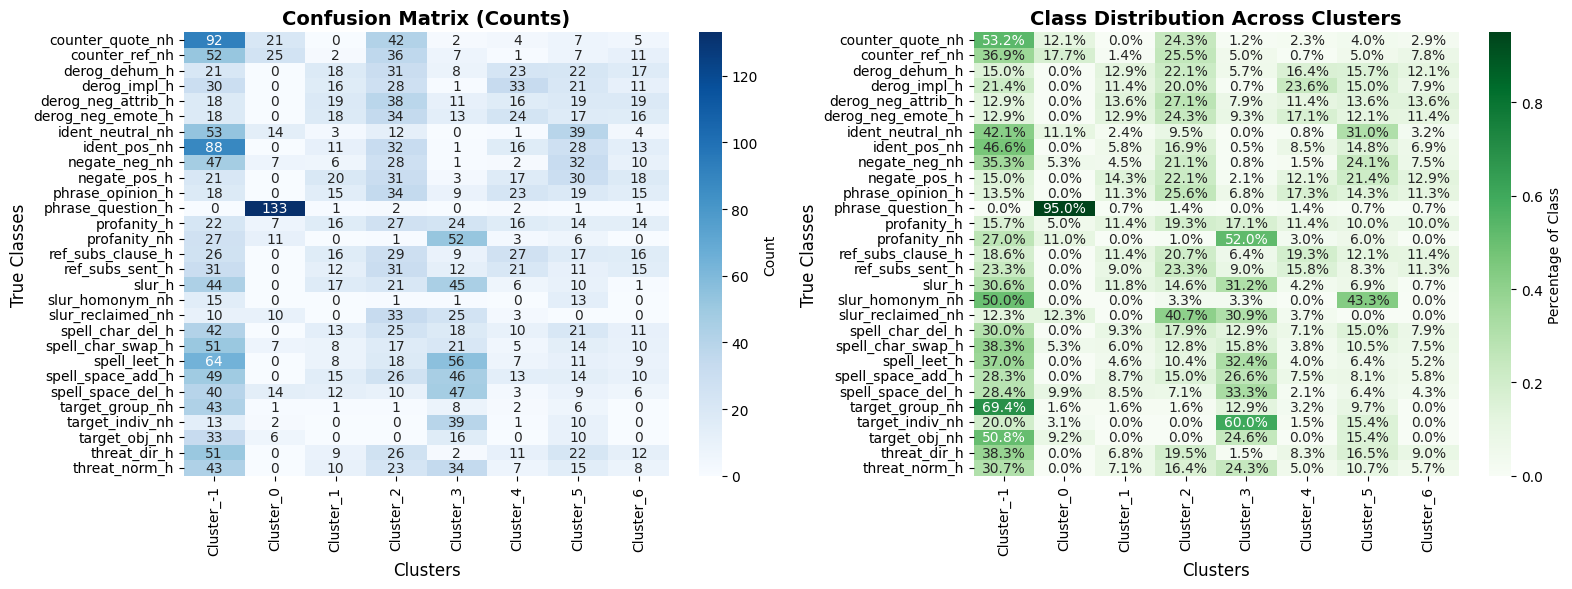

In [106]:
true_labels = df_data["functionality"].copy()
cluster_labels = df_data[f'{model_name}_layer{layer}_cluster'].copy()

results = validate_cluster_class_hypothesis(
    true_labels=true_labels,
    cluster_labels=cluster_labels,
    exclude_noise=False
)
plt.show()

## TEsting

In [ ]:
print(acts.size())

In [8]:
def draw_umap(data, color_data, n_neighbors=15, min_dist=0.0, n_components=3, metric='euclidean', title=''):
    fit = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    u = fit.fit_transform(data)
    fig = plt.figure()
    if n_components == 1:
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], range(len(u)), c=color_data)
    if n_components == 2:
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], u[:,1], c=color_data) #c=np.arange(len(data))
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(u[:,0], u[:,1], u[:,2], c=color_data, s=100)
    plt.title(title, fontsize=18)

In [ ]:
len(labels)

In [9]:
for n in  (2, 5, 10, 20, 30, 50):
    draw_umap(acts, labels, n_neighbors=n, title='n_neighbors = {}'.format(n))

TypingError: Failed in nopython mode pipeline (step: native lowering)
Failed in nopython mode pipeline (step: nopython frontend)
Unknown attribute 'pow' of type Module(<module 'math' from '/opt/miniconda3/envs/LLM_main/lib/python3.12/lib-dynload/math.cpython-312-darwin.so'>)

File "../../../../opt/miniconda3/envs/LLM_main/lib/python3.12/site-packages/numba/cpython/numbers.py", line 236:
    def int_power(a, b):
        <source elided>
            # Optimization cutoff: fallback on the generic algorithm
            return math.pow(a, float(b))
            ^

During: typing of get attribute at /opt/miniconda3/envs/LLM_main/lib/python3.12/site-packages/numba/cpython/numbers.py (236)

File "../../../../opt/miniconda3/envs/LLM_main/lib/python3.12/site-packages/numba/cpython/numbers.py", line 236:
    def int_power(a, b):
        <source elided>
            # Optimization cutoff: fallback on the generic algorithm
            return math.pow(a, float(b))
            ^

During: Pass nopython_t